# DSA210 — Notebook 2: Exploratory Data Analysis

**Prerequisites:** Run `01_data_cleaning_v2.ipynb` first to generate `master.csv` and `ev_timeseries.csv`.

| Plot | What it shows |
|------|---------------|
| 1 | EV charging infrastructure by geographic region (grouped, no 81-bar clutter) |
| 2 | Year-over-year EV growth rate: Turkey vs. World (fixes scale mismatch) |
| 3 | Normalised scatter: EVs vs. stations per 10k residents (fixes population bias) |
| 4 | Infrastructure gap: top-10 vs. bottom-10 provinces by stations per 10k (inequality) |

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

BASE    = Path('.')
FIGURES = BASE / 'figures'
FIGURES.mkdir(exist_ok=True)

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('Libraries loaded OK')

Libraries loaded OK


---
## Load Data

In [2]:
df_merged = pd.read_csv(BASE / 'master.csv')
df_ev_ts  = pd.read_csv(BASE / 'ev_timeseries.csv')

print(f'master.csv : {df_merged.shape}')
print(f'ev_timeseries.csv : {df_ev_ts.shape}')
df_merged.head(3)

master.csv : (81, 11)
ev_timeseries.csv : (22, 4)


,Province,Total_Stations,EV_Count,Population,Total_Vehicles,Car,Region,Is_Metropolitan,Stations_Per_Capita,EVs_Per_10k,Stations_Per_10k
0,Adana,222,10011,2283609.0,961667,455042,Mediterranean,1,9.721454,43.838503,0.972145
1,Adıyaman,29,1557,617821.0,162989,70781,Southeastern Anatolia,0,4.693916,25.201474,0.469392
2,Afyonkarahisar,159,2599,751808.0,325817,118124,Aegean,0,21.149017,34.569997,2.114902


---
## Plot 1 · EV Charging Infrastructure by Geographic Region

Groups all 81 provinces into Turkey's 7 geographic regions. Left panel = total stations; right panel = average stations per 100k residents (per-capita fairness).

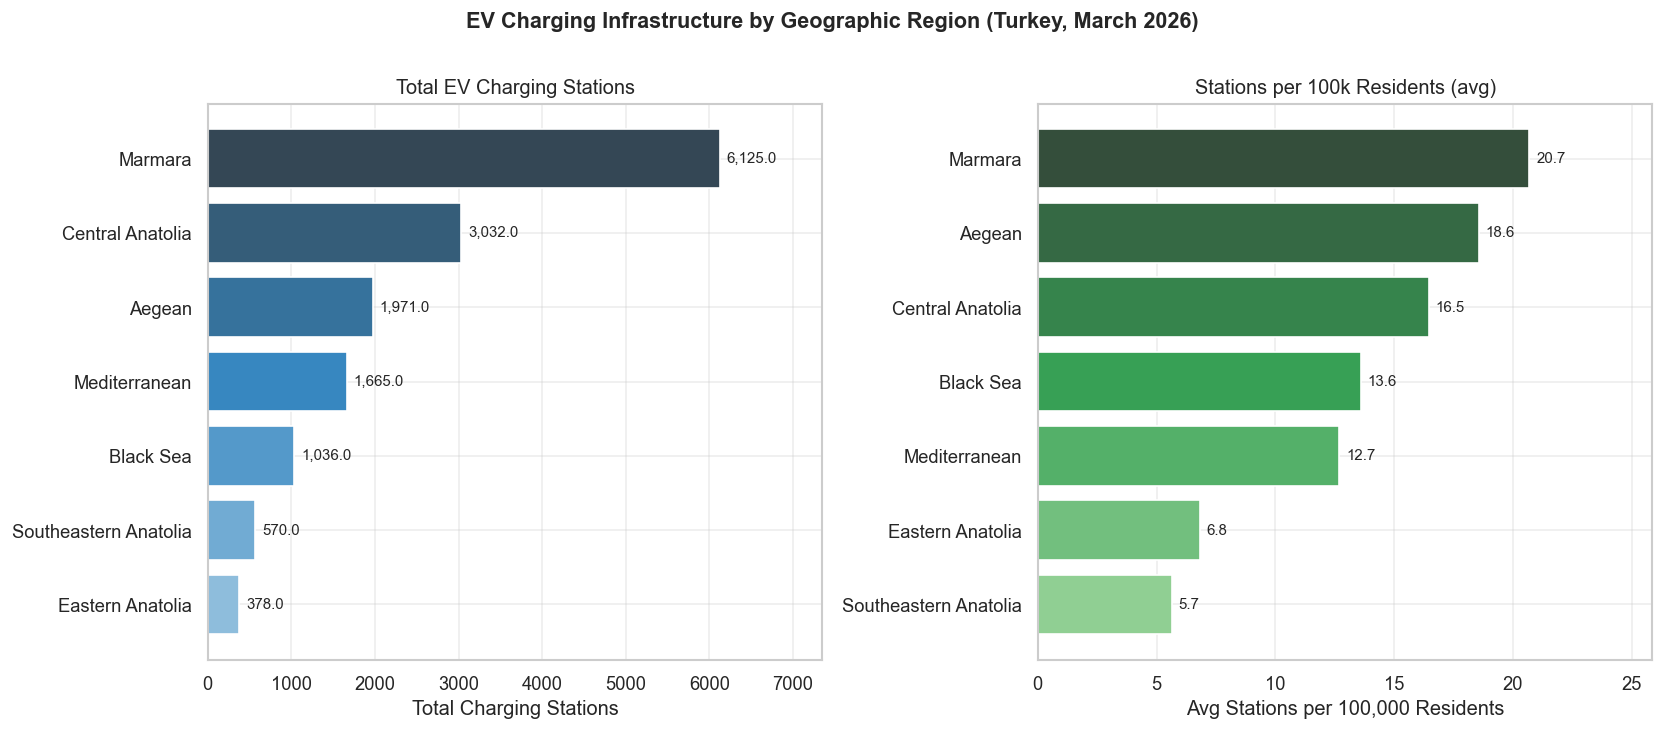

Saved plot1_regional_infrastructure.png


In [3]:
df_region = df_merged.groupby('Region', as_index=False).agg(
    Total_Stations   =('Total_Stations',    'sum'),
    Avg_Per_Capita   =('Stations_Per_Capita','mean')
).sort_values('Total_Stations', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: absolute count

bars1 = axes[0].barh(
    df_region['Region'], df_region['Total_Stations'],
    color=sns.color_palette('Blues_d', len(df_region))
)
axes[0].set_xlabel('Total Charging Stations')
axes[0].set_title('Total EV Charging Stations')
axes[0].bar_label(bars1, padding=4, fmt='{:,}', fontsize=9) 
axes[0].set_xlim(0, df_region['Total_Stations'].max() * 1.2)

# Right: per-capita

df_region_sorted2 = df_region.sort_values('Avg_Per_Capita', ascending=True)
bars2 = axes[1].barh(
    df_region_sorted2['Region'], df_region_sorted2['Avg_Per_Capita'],
    color=sns.color_palette('Greens_d', len(df_region))
)
axes[1].set_xlabel('Avg Stations per 100,000 Residents')
axes[1].set_title('Stations per 100k Residents (avg)')
axes[1].bar_label(bars2, padding=4, fmt='%.1f', fontsize=9)
axes[1].set_xlim(0, df_region_sorted2['Avg_Per_Capita'].max() * 1.25)

fig.suptitle('EV Charging Infrastructure by Geographic Region (Turkey, March 2026)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

for ax in axes:
    ax.grid(alpha=0.35) #for readability
plt.savefig(FIGURES / 'plot1_regional_infrastructure.png', bbox_inches='tight')

plt.show()
print('Saved plot1_regional_infrastructure.png')

The distribution of EV charging infrastructure is highly concentrated in the Marmara region in absolute terms, reflecting its economic dominance and population density. However, when adjusted for population, the differences between regions become less extreme, although Marmara still leads. Regions such as Eastern and Southeastern Anatolia remain significantly under-served even after normalization, indicating structural regional disparities in infrastructure access.

---
## Plot 2 · Year-over-Year EV Growth Rate: Turkey vs. World

Plotting **growth rates (%)** instead of absolute counts eliminates the scale mismatch between Turkey (thousands) and the world (millions).

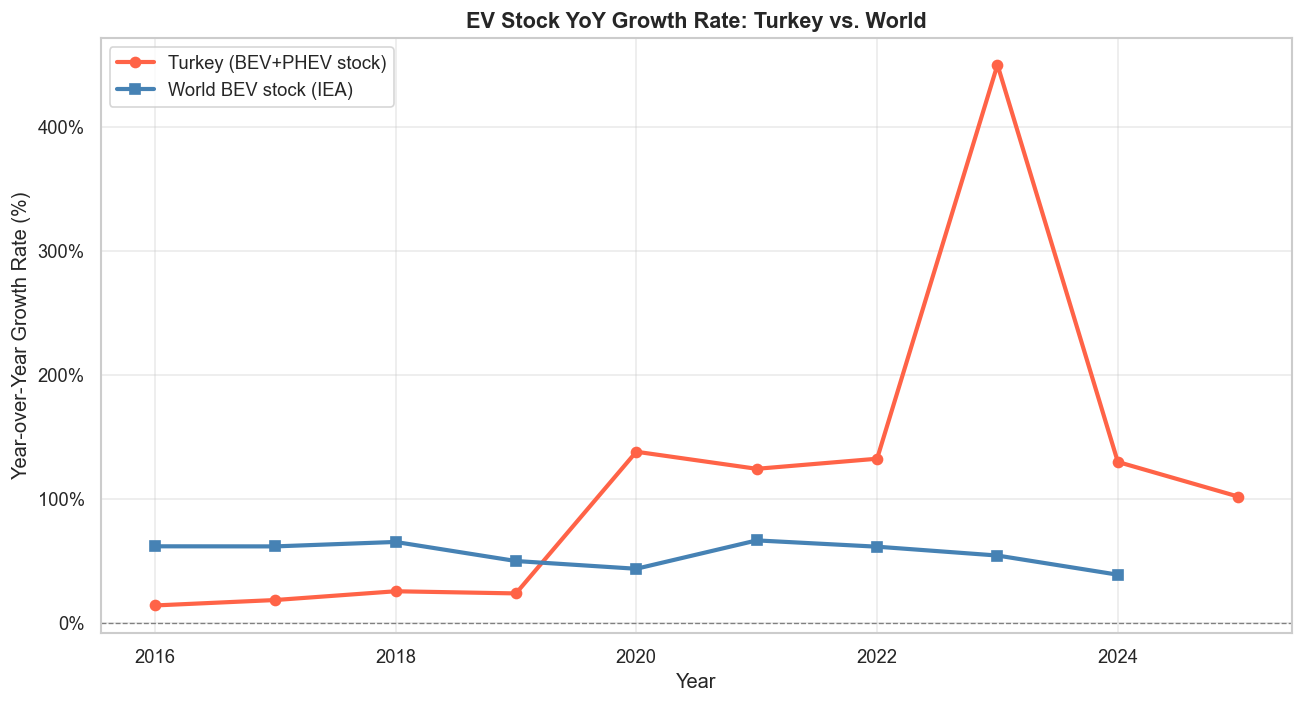

Saved plot2_yoy_growth_rate.png


In [4]:
# --- Turkey YoY ---
turkey_ts = df_ev_ts[df_ev_ts['Year'].between(2015, 2025)].copy()
turkey_ts = turkey_ts.sort_values('Year')
turkey_ts['Turkey_YoY'] = turkey_ts['Electric'].pct_change() * 100
turkey_ts = turkey_ts.dropna(subset=['Turkey_YoY'])

# --- Global YoY (IEA EV Data Explorer 2025) ---
df_global = pd.read_excel(
    BASE / 'EV Data Explorer 2025.xlsx',
    sheet_name='GEVO_EV_2025',
    engine='openpyxl'
)

df_world = df_global[
    (df_global['parameter']  == 'EV stock') &
    (df_global['mode']       == 'Cars') &
    (df_global['powertrain'] == 'BEV') &
    (df_global['category']   == 'Historical')
].groupby('year', as_index=False)['value'].sum()

df_world = df_world[df_world['year'].between(2015, 2024)].sort_values('year')
df_world['World_YoY'] = df_world['value'].pct_change() * 100
df_world = df_world.dropna(subset=['World_YoY'])

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(turkey_ts['Year'], turkey_ts['Turkey_YoY'],
        marker='o', linewidth=2.5, label='Turkey (BEV+PHEV stock)', color='tomato')
ax.plot(df_world['year'], df_world['World_YoY'],
        marker='s', linewidth=2.5, label='World BEV stock (IEA)', color='steelblue')

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Year-over-Year Growth Rate (%)')
ax.set_title('EV Stock YoY Growth Rate: Turkey vs. World', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES / 'plot2_yoy_growth_rate.png', bbox_inches='tight')
plt.show()
print('Saved plot2_yoy_growth_rate.png')


The year-over-year (YoY) growth rate shows that Turkey has experienced significantly higher growth compared to the global EV market, especially after 2020. 

However, this sharp increase ,particularly the spike around 2023, should be interpreted with caution. The high growth rate is largely driven by a low base effect, meaning that EV adoption in Turkey started from a relatively small number of vehicles. As a result, even moderate absolute increases translate into very high percentage growth.

In contrast, the global EV market exhibits more stable and gradually declining growth rates. This reflects a more mature market where the total number of EVs is already large, making percentage increases naturally smaller over time.

Overall, while Turkey appears to outperform the global average in growth rate, this primarily indicates an early-stage adoption phase rather than a larger absolute EV market.

---
## Plot 3 · Normalised Scatter: EVs vs. Stations per 10k Residents

By normalising both axes by population, large cities no longer dominate the chart. Bubble size = absolute station count. Colour = region.

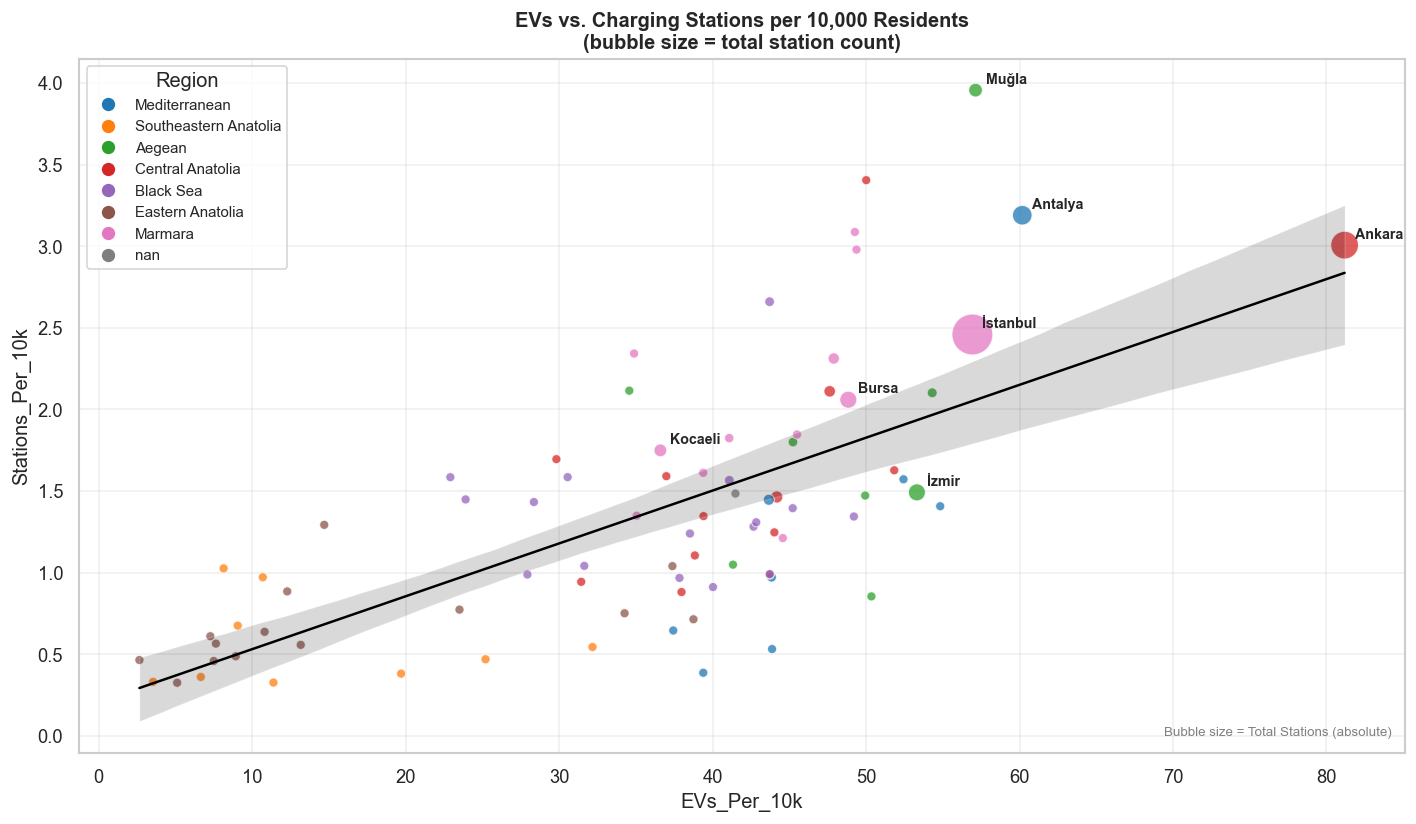

Saved plot3_normalised_scatter.png


In [5]:
df_scatter = df_merged.dropna(subset=['EVs_Per_10k', 'Stations_Per_10k']).copy()

regions    = df_scatter['Region'].unique()
palette    = sns.color_palette('tab10', len(regions))
color_map  = dict(zip(regions, palette))
colors     = df_scatter['Region'].map(color_map)
bubble_sz  = (df_scatter['Total_Stations'] / df_scatter['Total_Stations'].max() * 600).clip(lower=30)

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    df_scatter['EVs_Per_10k'],
    df_scatter['Stations_Per_10k'],
    s=bubble_sz,
    c=colors,
    alpha=0.75,
    edgecolors='white',
    linewidths=0.6
)

# Annotate top 7 provinces by Total_Stations
top7 = df_scatter.nlargest(7, 'Total_Stations')
for _, row in top7.iterrows():
    ax.annotate(
        row['Province'],
        (row['EVs_Per_10k'], row['Stations_Per_10k']),
        textcoords='offset points', xytext=(6, 4),
        fontsize=8.5, fontweight='bold'
    )

# Region legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[r],
           markersize=9, label=r)
    for r in regions
]
ax.legend(handles=legend_handles, title='Region', fontsize=9, loc='upper left')

# Bubble size note
ax.text(0.99, 0.02, 'Bubble size = Total Stations (absolute)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='grey')

ax.set_xlabel('EVs per 10,000 Residents')
ax.set_ylabel('Charging Stations per 10,000 Residents')
ax.set_title('EVs vs. Charging Stations per 10,000 Residents\n(bubble size = total station count)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

sns.regplot(
    data=df_scatter,
    x='EVs_Per_10k',
    y='Stations_Per_10k',
    scatter=False,
    ax=ax,
    color='black',
    line_kws={'linewidth':1.5}
)

plt.tight_layout()
plt.savefig(FIGURES / 'plot3_normalised_scatter.png', bbox_inches='tight')
plt.show()
print('Saved plot3_normalised_scatter.png')

There is a clear positive relationship between EV density and charging infrastructure. However, several cities deviate from the trend line, indicating regional imbalances where some cities are under-served (e.g., İzmir) while others appear relatively over-served (e.g., Muğla).

---
## Plot 4 · Infrastructure Gap: Top-10 vs. Bottom-10 Provinces

Highlights the inequality in EV infrastructure access across Turkey — the provinces best served vs. most underserved by stations per 10,000 residents.

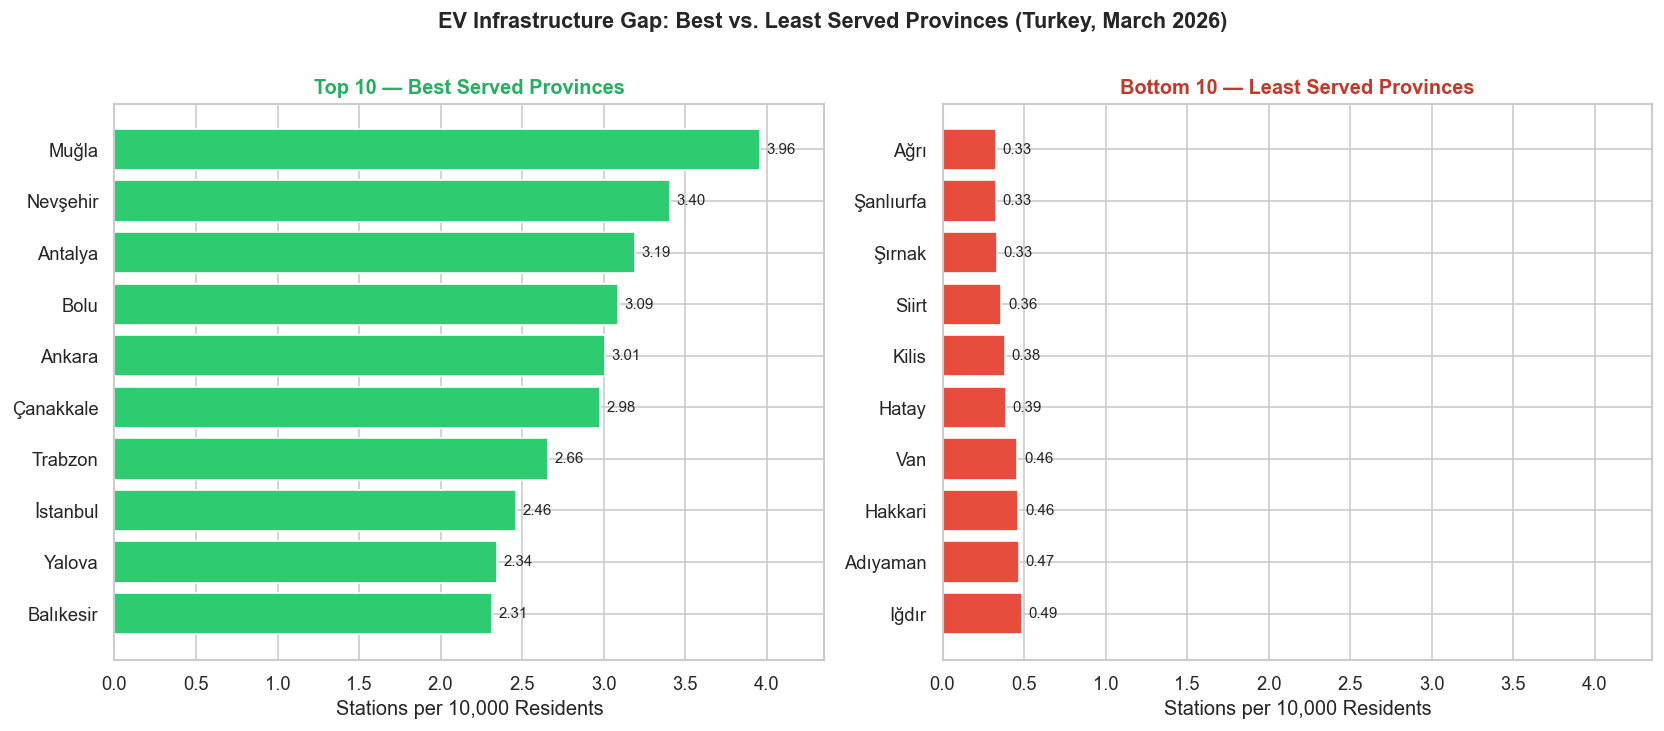

Saved plot4_infrastructure_gap.png

Top-10 avg: 2.94  |  Bottom-10 avg: 0.40
Ratio (top / bottom): 7.4x


In [6]:
df_gap = df_merged[['Province', 'Stations_Per_10k', 'Region']].dropna().copy()
df_gap = df_gap.sort_values('Stations_Per_10k', ascending=False)

top10    = df_gap.head(10).copy()
bottom10 = df_gap.tail(10).copy()

top10['Group']    = 'Top 10 (Most Served)'
bottom10['Group'] = 'Bottom 10 (Least Served)'
df_combined = pd.concat([top10, bottom10])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
max_val = df_gap['Stations_Per_10k'].max()

# Top 10
top_sorted = top10.sort_values('Stations_Per_10k', ascending=True)
bars_top = axes[0].barh(
    top_sorted['Province'], top_sorted['Stations_Per_10k'],
    color='#2ecc71'
)
axes[0].set_title('Top 10 — Best Served Provinces', fontweight='bold', color='#27ae60')
axes[0].set_xlabel('Stations per 10,000 Residents')
axes[0].bar_label(bars_top, padding=4, fmt='%.2f', fontsize=9)
axes[0].set_xlim(0, max_val * 1.1)

# Bottom 10
bot_sorted = bottom10.sort_values('Stations_Per_10k', ascending=False)
bars_bot = axes[1].barh(
    bot_sorted['Province'], bot_sorted['Stations_Per_10k'],
    color='#e74c3c'
)
axes[1].set_title('Bottom 10 — Least Served Provinces', fontweight='bold', color='#c0392b')
axes[1].set_xlabel('Stations per 10,000 Residents')
axes[1].bar_label(bars_bot, padding=4, fmt='%.2f', fontsize=9)
axes[1].set_xlim(0, max_val * 1.1)

fig.suptitle('EV Infrastructure Gap: Best vs. Least Served Provinces (Turkey, March 2026)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'plot4_infrastructure_gap.png', bbox_inches='tight')
plt.show()
print('Saved plot4_infrastructure_gap.png')

#  ratio summary
ratio = top10['Stations_Per_10k'].mean() / bottom10['Stations_Per_10k'].mean()
print(f"\nTop-10 avg: {top10['Stations_Per_10k'].mean():.2f}  |  Bottom-10 avg: {bottom10['Stations_Per_10k'].mean():.2f}")
print(f"Ratio (top / bottom): {ratio:.1f}x")

A substantial disparity exists in EV charging infrastructure across provinces. The best-served provinces have significantly higher station availability per capita compared to the least-served ones, with differences approaching an order of magnitude.

This highlights a clear regional inequality in infrastructure distribution, particularly disadvantaging provinces in Eastern and Southeastern Turkey.